# 01 - Exploration & Opportunity for Savings Analysis

This notebook performs exploratory data analysis (EDA) on the HVAC and occupancy data,
and computes the "opportunity for savings" - periods when zones are unoccupied but HVAC is running.

## Goals
1. Load and explore raw occupancy and HVAC data
2. Understand data quality, gaps, and distributions
3. Merge occupancy and HVAC data by zone and timestamp
4. Identify "opportunity" periods (zero occupancy + HVAC on)
5. Quantify potential energy and cost savings
6. Create visualizations for the end-of-quarter presentation

Mean Absolute Error: 72.14 people
Test data starts at: 2019-01-14 10:00:00
Test data ends at: 2019-05-20 12:00:00


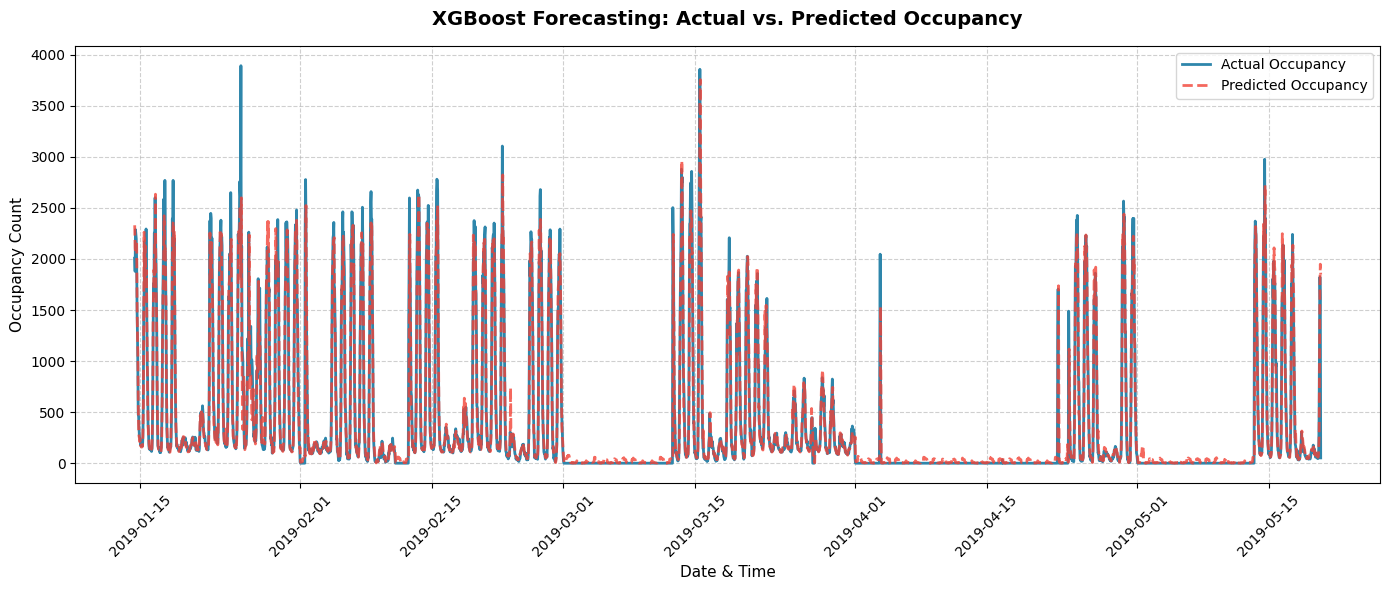

AttributeError: 'occupancy_predictor' object has no attribute 'print_predictions'

In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
import sys
sys.path.append('..')
from src.data import load_occupancy, load_hvac, merge_occupancy_hvac, fetch_historical_weather
from src.viz import plot_occupancy_over_time
from src.models.xgBoost import occupancy_predictor

# 1. Load and prepare the raw occupancy data
raw_df = pd.read_csv('../src/data/ap_occupancy_15min_raw.csv')

# 2. Load and prepare the weather data
weather_df = pd.read_csv('../src/data/irvine_weather.csv')
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])
weather_df = weather_df.set_index('timestamp')

# 3. Create predictor instance and build the model
predictor = occupancy_predictor()
predictor.prepare_data(raw_df, time_col='interval_begin').create_features(weather_df=weather_df).train_and_evaluate()

# 4. Visualize the results
fig = predictor.plot_actual_vs_predicted()
# Check the start and end dates of your test set
print("Test data starts at:", predictor.y_test.index.min())
print("Test data ends at:", predictor.y_test.index.max())
plt.show()
predictor.print_predictions()
%matplotlib inline

## 1. Load Raw Data

Load occupancy and HVAC data from `data/raw/`.

**TODO:** Update paths once raw data files are in place.

In [ ]:
# TODO: Load occupancy data
# occ_df = load_occupancy('../data/raw/occupancy/occupancy_data.csv')
# occ_df.head()

In [ ]:
# TODO: Load HVAC data
# hvac_df = load_hvac('../data/raw/hvac/hvac_data.csv')
# hvac_df.head()

## 2. Data Exploration

Explore data quality, distributions, and time ranges.

In [ ]:
# TODO: Check data shapes, dtypes, missing values
# print(f"Occupancy data shape: {occ_df.shape}")
# print(f"HVAC data shape: {hvac_df.shape}")
# occ_df.info()

In [ ]:
# TODO: Check time ranges and frequency
# print(f"Occupancy time range: {occ_df['timestamp'].min()} to {occ_df['timestamp'].max()}")
# print(f"HVAC time range: {hvac_df['timestamp'].min()} to {hvac_df['timestamp'].max()}")

## 3. Merge Occupancy and HVAC Data

In [ ]:
# TODO: Merge datasets
# merged_df = merge_occupancy_hvac(occ_df, hvac_df, freq='15min')
# merged_df.head()

## 4. Opportunity for Savings Analysis

Identify periods where:
- Occupancy is zero (or below threshold)
- HVAC is actively running (consuming energy)

These represent the maximum potential savings from occupancy-aware control.

In [ ]:
# TODO: Compute opportunity flag
# merged_df['is_opportunity'] = (merged_df['occupancy_count'] == 0) & (merged_df['hvac_on'])
# print(f"Total opportunity periods: {merged_df['is_opportunity'].sum()}")
# print(f"Percent of time: {merged_df['is_opportunity'].mean() * 100:.1f}%")

In [ ]:
# TODO: Compute energy and cost during opportunity periods
# opportunity_energy = merged_df.loc[merged_df['is_opportunity'], 'energy_kwh'].sum()
# total_energy = merged_df['energy_kwh'].sum()
# print(f"Opportunity energy: {opportunity_energy:.0f} kWh")
# print(f"Total HVAC energy: {total_energy:.0f} kWh")
# print(f"Potential savings: {opportunity_energy / total_energy * 100:.1f}%")

## 5. Visualizations

Create plots for the end-of-quarter presentation.

In [ ]:
# TODO: Plot occupancy heatmap (hour x day of week)
# fig = plot_occupancy_heatmap(merged_df)
# plt.show()

In [ ]:
# TODO: Plot daily opportunity for savings over time
# fig = plot_daily_opportunity_for_savings(daily_df)
# plt.show()

In [ ]:
# TODO: Plot example day timeline
# fig = plot_example_day_timeline(merged_df, date='2024-01-15', zone_id='BH-101')
# plt.show()

## 6. Summary & Next Steps

**Findings:**
- TODO: Summarize key findings

**Next Steps:**
- TODO: List next analysis steps